# Эконометрическое моделирование влияния цифровой трансформации организаций на региональное экономическое развитие Российской Федерации

=== ЭКОНОМЕТРИЧЕСКИЙ АНАЛИЗ ЦИФРОВОЙ ТРАНСФОРМАЦИИ ===

Размерность данных: 82 строк, 10 столбцов

Первые 5 строк:
                 Регион  \
0  Белгородская область   
1      Брянская область   
2  Владимирская область   
3   Воронежская область   
4    Ивановская область   

   Организации, использовавшие персональные компьютеры, %  \
0                                            88.4591        
1                                            82.1386        
2                                            86.3158        
3                                            84.2656        
4                                            84.2410        

   Организации, использовавшие «облачные» сервисы, %  \
0                                            30.0629   
1                                            20.9852   
2                                            27.9605   
3                                            26.1742   
4                                            24.7229   

   Организации, ис

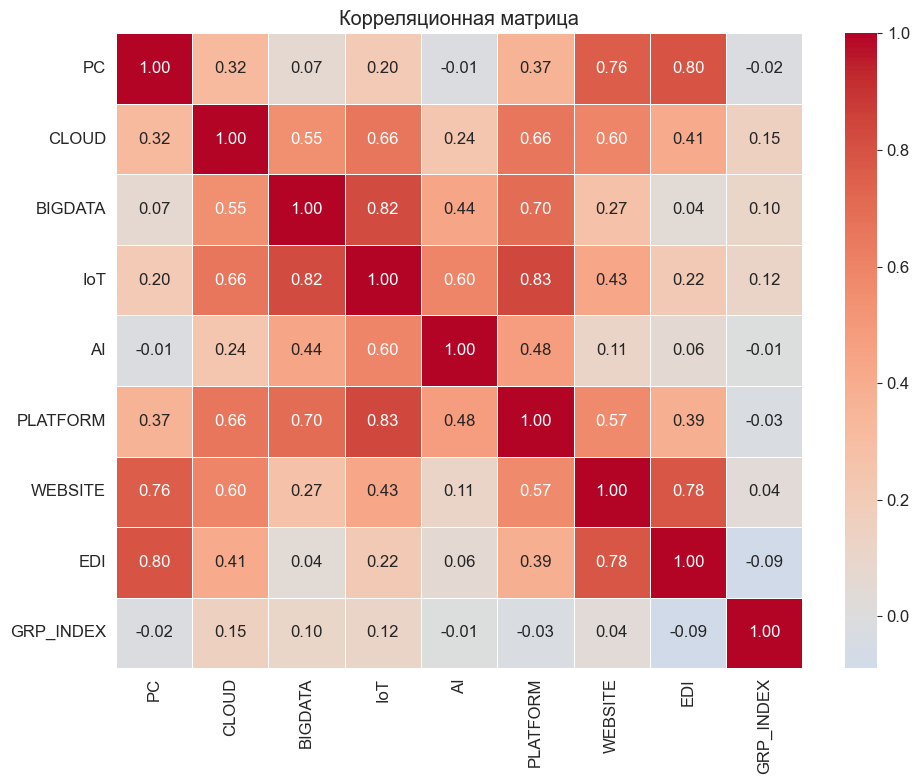


=== БАЗОВАЯ OLS МОДЕЛЬ ===
                            OLS Regression Results                            
Dep. Variable:              GRP_INDEX   R-squared:                       0.123
Model:                            OLS   Adj. R-squared:                  0.027
Method:                 Least Squares   F-statistic:                     1.278
Date:                Fri, 22 May 2026   Prob (F-statistic):              0.269
Time:                        00:00:16   Log-Likelihood:                -335.44
No. Observations:                  82   AIC:                             688.9
Df Residuals:                      73   BIC:                             710.5
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         99.4308   

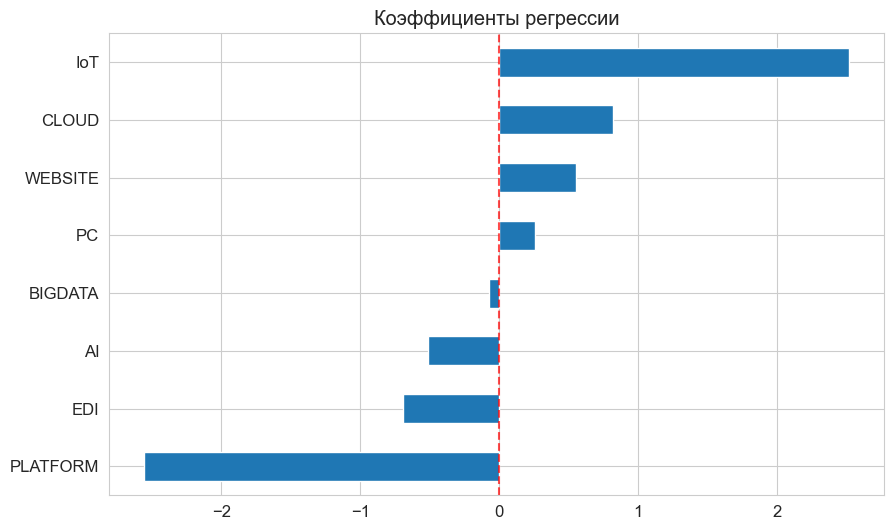


=== АНАЛИЗ ЗАВЕРШЁН ===
Все графики сохранены в папке output/


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ===================== НАСТРОЙКИ =====================
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")
print("=== ЭКОНОМЕТРИЧЕСКИЙ АНАЛИЗ ЦИФРОВОЙ ТРАНСФОРМАЦИИ ===\n")

# ===================== 1. ЗАГРУЗКА ДАННЫХ =====================
data = pd.read_excel("data/dataa.xlsx")

print(f"Размерность данных: {data.shape[0]} строк, {data.shape[1]} столбцов")
print("\nПервые 5 строк:")
print(data.head())

# Переименование колонок
data.columns = ["Region", "PC", "CLOUD", "BIGDATA", "IoT", "AI", 
                "PLATFORM", "WEBSITE", "EDI", "GRP_INDEX"]

print("\n=== ОПИСАТЕЛЬНАЯ СТАТИСТИКА ===")
print(data.describe().round(4))

# ===================== 2. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ =====================
print("\n=== КОРРЕЛЯЦИОННЫЙ АНАЛИЗ ===")

corr_matrix = data.drop(columns=['Region']).corr()

print("Корреляции с GRP_INDEX (по убыванию):")
print(corr_matrix['GRP_INDEX'].sort_values(ascending=False).round(3))

# Тепловая карта
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('Корреляционная матрица')
plt.tight_layout()
plt.savefig('output/correlation_heatmap.png', dpi=300)
plt.show()

# ===================== 3. БАЗОВАЯ РЕГРЕССИОННАЯ МОДЕЛЬ =====================
print("\n=== БАЗОВАЯ OLS МОДЕЛЬ ===")

X = data[["PC", "CLOUD", "BIGDATA", "IoT", "AI", "PLATFORM", "WEBSITE", "EDI"]]
X = sm.add_constant(X)
y = data["GRP_INDEX"]

model = sm.OLS(y, X).fit()

print(model.summary())

# ===================== 4. VIF (мультиколлинеарность) =====================
print("\n=== VIF (Фактор инфляции дисперсии) ===")
vif_data = pd.DataFrame()
vif_data["Переменная"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data.round(3))

# ===================== 5. АНАЛИЗ КОЭФФИЦИЕНТОВ =====================
print("\n=== КОЭФФИЦИЕНТЫ МОДЕЛИ ===")
coef = pd.DataFrame({
    'Коэффициент': model.params,
    'Std Err': model.bse,
    't-value': model.tvalues,
    'P-value': model.pvalues
}).round(4)
print(coef)

# Положительные / отрицательные
positive = (model.params > 0).sum() - 1  # без константы
print(f"\nПоложительных коэффициентов: {positive} из 8")

# ===================== 6. ДИАГНОСТИКА МОДЕЛИ =====================
print("\n=== ДИАГНОСТИКА МОДЕЛИ ===")

# Нормальность остатков (Shapiro-Wilk)
shapiro_test = stats.shapiro(model.resid)
print(f"Тест Шапиро-Уилка: W = {shapiro_test.statistic:.4f}, p-value = {shapiro_test.pvalue:.4f}")

# Гетероскедастичность (Breusch-Pagan)
bp_test = het_breuschpagan(model.resid, model.model.exog)
print(f"Тест Бройша-Пагана: p-value = {bp_test[1]:.4f}")

# ===================== 7. ПАРНЫЕ РЕГРЕССИИ =====================
print("\n=== ПАРНЫЕ РЕГРЕССИИ (по убыванию R²) ===")
variables = ["PC", "CLOUD", "BIGDATA", "IoT", "AI", "PLATFORM", "WEBSITE", "EDI"]
results = []

for var in variables:
    model_simple = smf.ols(f"GRP_INDEX ~ {var}", data=data).fit()
    results.append({
        'Переменная': var,
        'R²': model_simple.rsquared,
        'Коэффициент': model_simple.params[var],
        'P-value': model_simple.pvalues[var]
    })

simple_df = pd.DataFrame(results).sort_values('R²', ascending=False)
print(simple_df.round(4))

# ===================== 8. СОХРАНЕНИЕ ГРАФИКОВ =====================
# График коэффициентов
plt.figure(figsize=(10, 6))
model.params[1:].sort_values().plot(kind='barh')
plt.title('Коэффициенты регрессии')
plt.axvline(0, color='red', linestyle='--', alpha=0.7)
plt.savefig('output/coefficients.png', dpi=300)
plt.show()

print("\n=== АНАЛИЗ ЗАВЕРШЁН ===")
print("Все графики сохранены в папке output/")